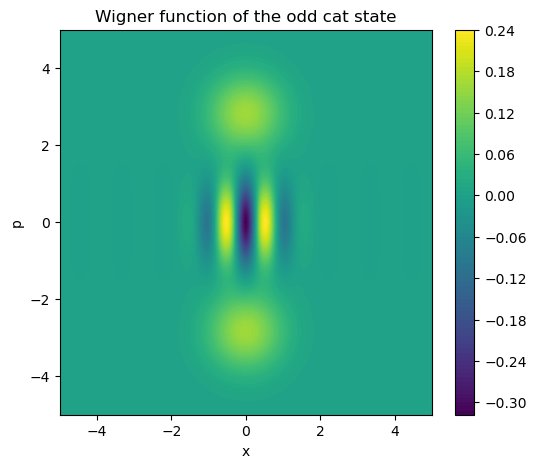

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

alpha = 2.0
N = 80

coh_1 = coherent(N, 1j * alpha)
coh_2 = coherent(N, -1j * alpha)

odd_cat = coh_1 - coh_2
odd_cat = odd_cat.unit()

x = np.linspace(-5, 5, 500)
W = wigner(odd_cat, x, x)  # wigner function

plt.figure(figsize=(6,5))
plt.contourf(x, x, W, 100)
plt.colorbar()
plt.title("Wigner function of the odd cat state")
plt.xlabel('x')
plt.ylabel('p')
plt.show()


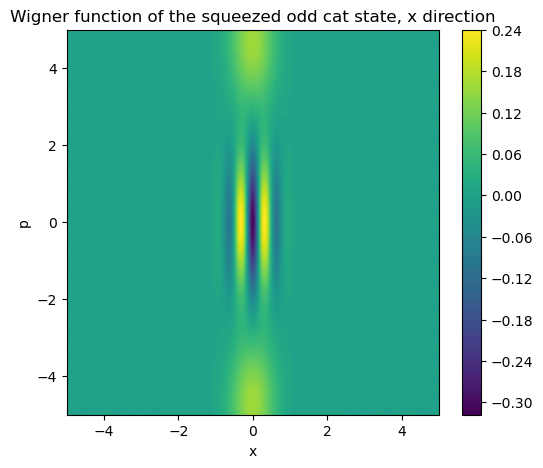

In [2]:
r = 0.5   # radius
phi = 0.0  # angle, zero for squeezing in x direction

S = squeeze(N, r * np.exp(1j * phi))   # squeezing operator

odd_cat_squeezed = S * odd_cat
W_squeezed = wigner(odd_cat_squeezed, x, x)  # wigner function for squeezed odd cat state, x direction

plt.figure(figsize=(6,5))
plt.contourf(x, x, W_squeezed, 100)
plt.colorbar()
plt.title("Wigner function of the squeezed odd cat state, x direction")
plt.xlabel('x')
plt.ylabel('p')
plt.show()

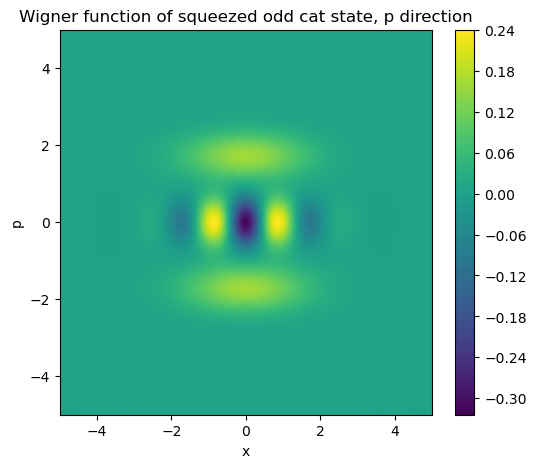

In [3]:
r = 0.5
phi_p = np.pi   # pi for squeezing in p direction

S_p = squeeze(N, r * np.exp(1j * phi_p))
odd_cat_squeezed_p = S_p * odd_cat

W_squeezed_p = wigner(odd_cat_squeezed_p, x, x)   # wigner function for squeezed odd cat state, p direction

plt.figure(figsize=(6,5))
plt.contourf(x, x, W_squeezed_p, 100)
plt.colorbar()
plt.title("Wigner function of squeezed odd cat state, p direction")
plt.xlabel('x')
plt.ylabel('p')
plt.show()


E:\Anaconda\envs\qutip-env\lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
E:\Anaconda\envs\qutip-env\lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


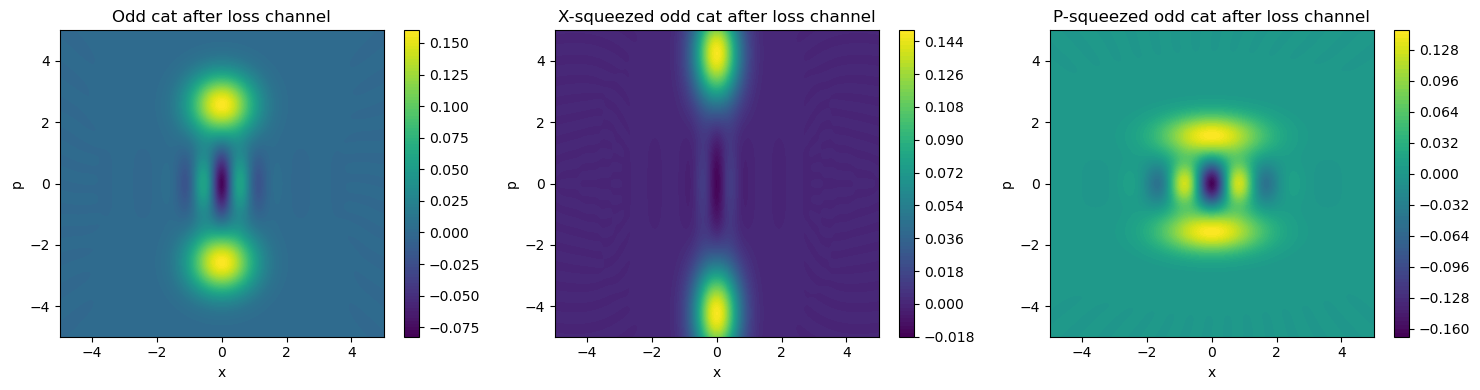

The state that retains the most Wigner negativity is: P-squeezed odd cat
Minimum Wigner values: {'Odd cat': np.float64(-0.08001337703576031), 'X-squeezed odd cat': np.float64(-0.01634600454739752), 'P-squeezed odd cat': np.float64(-0.16613060114183076)}


In [4]:
# exercise 2
alpha = 2.0
N = 50
r = 0.5
gamma = 1.5
omega = 50.0
t = 2* np.pi / omega
t_list = np.linspace(0, t, 100)
phi_x = 0.0     # squeezing phase for X direction
phi_p = np.pi   # squeezing phase for P direction
opts = Options(nsteps=1000000)

# annihilation operator, hamiltonian, collapse operator
a = destroy(N)
H = omega * (a.dag() * a + 0.5)
c_ops = [np.sqrt(gamma) * a]   # collapse operator for vacuum state, n_th = 0

coh_1 = coherent(N, 1j * alpha)
coh_2 = coherent(N, -1j * alpha)
psi_odd_cat = (coh_1 - coh_2).unit()

# squeezing operators
S_x = squeeze(N, r * np.exp(1j * phi_x))
S_p = squeeze(N, r * np.exp(1j * phi_p))

# squeezed cat states
psi_squeezed_x = S_x * psi_odd_cat
psi_squeezed_p = S_p * psi_odd_cat

# initial states
states = [psi_odd_cat, psi_squeezed_x, psi_squeezed_p]
state_labels = ['Odd cat', 'X-squeezed odd cat', 'P-squeezed odd cat']

# final states
final_states = []
for psi in states:
    result = mesolve(H, psi, t_list, c_ops, [], options = opts)
    final_states.append(result.states[-1])


# Plot
plt.figure(figsize=(15, 4))
min_wigner_vals = []
for i, rho in enumerate(final_states):
    W = wigner(rho, x, x)
    min_wigner_vals.append(W.min())
    
    plt.subplot(1, 3, i+1)
    plt.contourf(x, x, W, 100)
    plt.colorbar()
    plt.title(f'{state_labels[i]} after loss channel')
    plt.xlabel('x')
    plt.ylabel('p')
    
plt.tight_layout()
plt.show()

# Determine which retains the most Wigner negativity (minimum Wigner value)
most_negative_index = np.argmin(min_wigner_vals)
print(f"The state that retains the most Wigner negativity is: {state_labels[most_negative_index]}")
print(f"Minimum Wigner values: {dict(zip(state_labels, min_wigner_vals))}")


In [5]:
from qutip import fidelity

# Inverse squeezing operators
Sx_inv = squeeze(N, -r * np.exp(1j * phi_x))
Sp_inv = squeeze(N, -r * np.exp(1j * phi_p))

# Apply inverse squeezing to final states
# [Note: only apply to states that were originally squeezed]
rho_cat = final_states[0]  # no squeezing to undo
rho_sx_unsqueezed = Sx_inv * final_states[1] * Sx_inv.dag()
rho_sp_unsqueezed = Sp_inv * final_states[2] * Sp_inv.dag()

# Fidelity with the original pure odd cat state
f_cat = fidelity(psi_odd_cat, rho_cat)
f_sx = fidelity(psi_odd_cat, rho_sx_unsqueezed)
f_sp = fidelity(psi_odd_cat, rho_sp_unsqueezed)

# Print results
print("Fidelity with original odd cat state:")
print(f"  No squeezing:     {f_cat:.4f}")
print(f"  Squeezed in X:    {f_sx:.4f}")
print(f"  Squeezed in P:    {f_sp:.4f}")

# Determine best
fidelities = [f_cat, f_sx, f_sp]
labels = ['No squeezing', 'Squeezed in X', 'Squeezed in P']
best_idx = np.argmax(fidelities)
print(f"\n→ Highest fidelity: {labels[best_idx]}")


Fidelity with original odd cat state:
  No squeezing:     0.7785
  Squeezed in X:    0.6941
  Squeezed in P:    0.8587

→ Highest fidelity: Squeezed in P


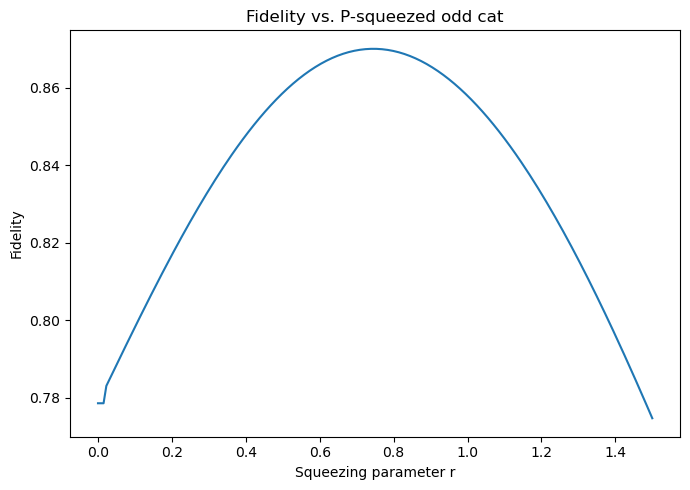

Optimal squeezing parameter r ≈ 0.746
Maximum fidelity ≈ 0.8701


In [6]:
# Range of squeezing parameters r
r_vals = np.linspace(0, 1.5, 200)
fidelities = []

for r in r_vals:
    # Apply squeezing
    S = squeeze(N, -r)  # squeezing in P direction
    psi_squeezed = S * psi_odd_cat

    # Evolve through loss channel
    result = mesolve(H, psi_squeezed, t_list, c_ops, [], options=opts)
    rho_out = result.states[-1]

    # Undo squeezing
    S_inv = squeeze(N, r)
    rho_unsqueezed = S_inv * rho_out * S_inv.dag()

    # Fidelity with initial state
    F = fidelity(psi_odd_cat, rho_unsqueezed)
    fidelities.append(F)

# Plot fidelity vs. r
plt.figure(figsize=(7,5))
plt.plot(r_vals, fidelities)
plt.xlabel("Squeezing parameter r")
plt.ylabel("Fidelity")
plt.title("Fidelity vs. P-squeezed odd cat")
plt.tight_layout()
plt.show()

# Find optimal r
max_fid = max(fidelities)
optimal_r = r_vals[np.argmax(fidelities)]
print(f"Optimal squeezing parameter r ≈ {optimal_r:.3f}")
print(f"Maximum fidelity ≈ {max_fid:.4f}")

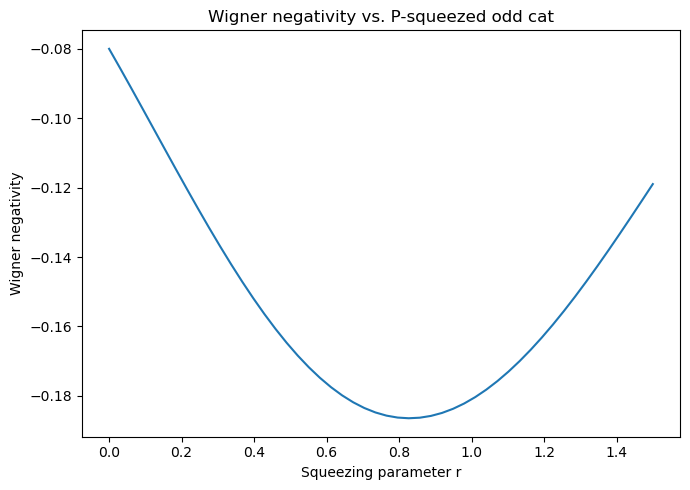

Optimal squeezing parameter for max Wigner negativity: r ≈ 0.827
Minimum Wigner value ≈ -0.18645


In [8]:
negativities = []
r_vals = np.linspace(0, 1.5, 50)

for r in r_vals:
    # Apply squeezing in P
    S = squeeze(N, -r)
    psi_squeezed = S * psi_odd_cat

    # Evolve through lossy channel
    result = mesolve(H, psi_squeezed, t_list, c_ops, [], options=opts)
    rho_out = result.states[-1]

    # Undo squeezing
    S_inv = squeeze(N, r)
    rho_unsqueezed = S_inv * rho_out * S_inv.dag()

    # Compute Wigner function
    W = wigner(rho_unsqueezed, x, x)
    minW = W.min()
    negativities.append(minW)

# Plot Wigner negativity vs. r
plt.figure(figsize=(7,5))
plt.plot(r_vals, negativities)
plt.xlabel("Squeezing parameter r")
plt.ylabel("Wigner negativity")
plt.title("Wigner negativity vs. P-squeezed odd cat")
plt.tight_layout()
plt.show()

# Report optimal r (most negative Wigner point)
min_neg = min(negativities)
optimal_r = r_vals[np.argmin(negativities)]
print(f"Optimal squeezing parameter for max Wigner negativity: r ≈ {optimal_r:.3f}")
print(f"Minimum Wigner value ≈ {min_neg:.5f}")